In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
import glob 
from src import dmbeat
from src.psrsigsim.signal.fb_signal import FilterBankSignal
from src.psrsigsim.pulsar.profiles import GaussProfile
from src.psrsigsim.pulsar.pulsar import Pulsar
from src.psrsigsim.ism.ism import ISM

%matplotlib widget

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [ ]:
# High-RM pulsars show up at high delay.
# Kumar+26 gives polarization profiles for many southern pulsars (see Fig 7 and Fig 8). 
# By inspection of their Fig. 8 (multifrequency), 
# the linear component of pulse phase is roughly a Gaussian with amplitude ~0.53 of Stokes I at 70.7 MHz,
# ~0.66 of Stokes I at 131.6 MHz, ~0.65 of Stokes I at 169.1 MHz, ~0.56 of Stokes I at 196.5 MHz, ~0.57 of Stokes I at 224.6 MHz.
# We take a fiducial L ~ 0.6.
# Circular polarization is -0.07--0.09 (negative) at 70.7 and 224.6 MHz, but less than that at intermediate frequencies.
# We take a fiducial V ~ 0.05.

In [48]:
150/1230/4

0.03048780487804878

100% dispersed in 6.182 seconds.

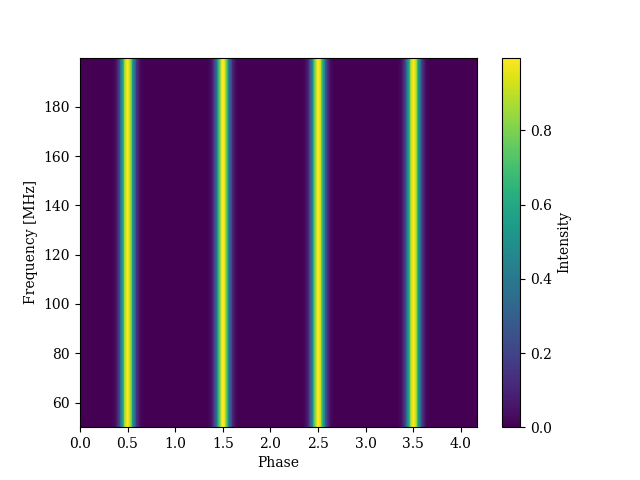

In [10]:
# Define our signal variables.
f0 = 125 # center observing frequecy in MHz
bw = 150 # observation MHz
Nf = 1230*2**8 #256 # number of frequency channels
f_samp = 0.0001 # sample rate of data in MHz (here 0.6554 ms for size purposes)
# Now we define our signal
signal_1 = FilterBankSignal(fcent = f0, bandwidth = bw, Nsubband=Nf, sample_rate=f_samp, fold = False)
# We define the Guassian profile
gauss_prof = GaussProfile(peak = 0.5, width = 0.05, amp = 1.0)
# We want to use 2048 phase bins and just one frequency channel for this test.
gauss_prof.init_profiles(2048, Nchan = 1)

# Define the values needed for the puslar
period = 1.2 # pulse period of our simulated pulsar, here one second
Smean = 10.0 # The mean flux of the pulsar, here 10.0 Jy (note that this is very bright for a pulsar)
psr_name = "J0630-2834" # The name of our simulated pulsar
# psr_name_b = 'B0628-28'
# Now we define the pulsar
pulsar_1 = Pulsar(period, Smean, profiles=gauss_prof, name = psr_name)

# Define the dispersion measure
dm = 0 #34.0 # pc cm^-3
# And define the ISM object, note that this class takes no initial arguements
ism_1 = ISM()

# define the observation length
obslen = 5.0 # seconds
pulsar_1.make_pulses(signal_1, tobs = obslen)
ism_1.disperse(signal_1, dm)

phases = np.linspace(0, obslen/period, len(signal_1.data[0,:]))
plt.figure()
plt.imshow(signal_1.data, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value])
plt.ylabel("Frequency [MHz]")
plt.xlabel("Phase")
plt.colorbar(label = "Intensity")
#plt.xlim(0,10)

plt.show()

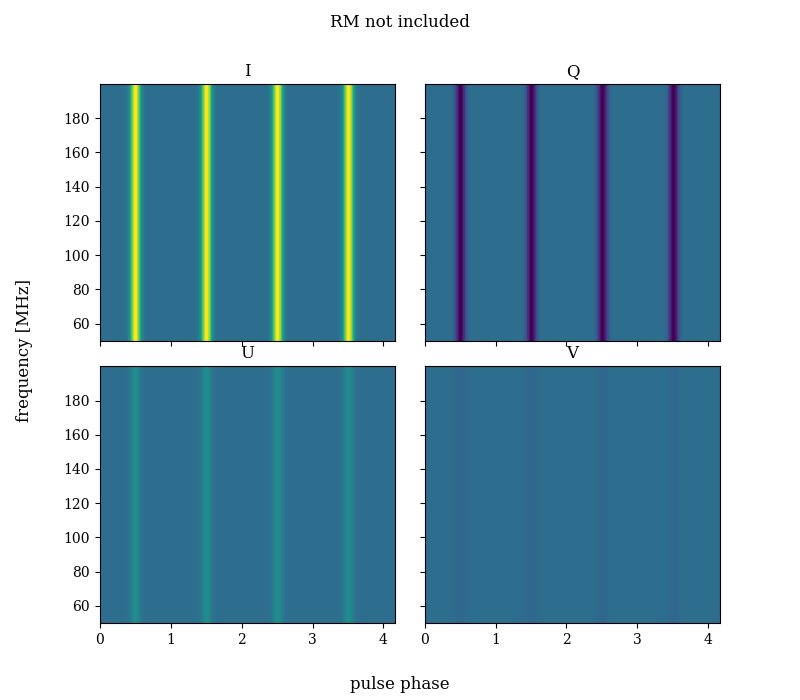

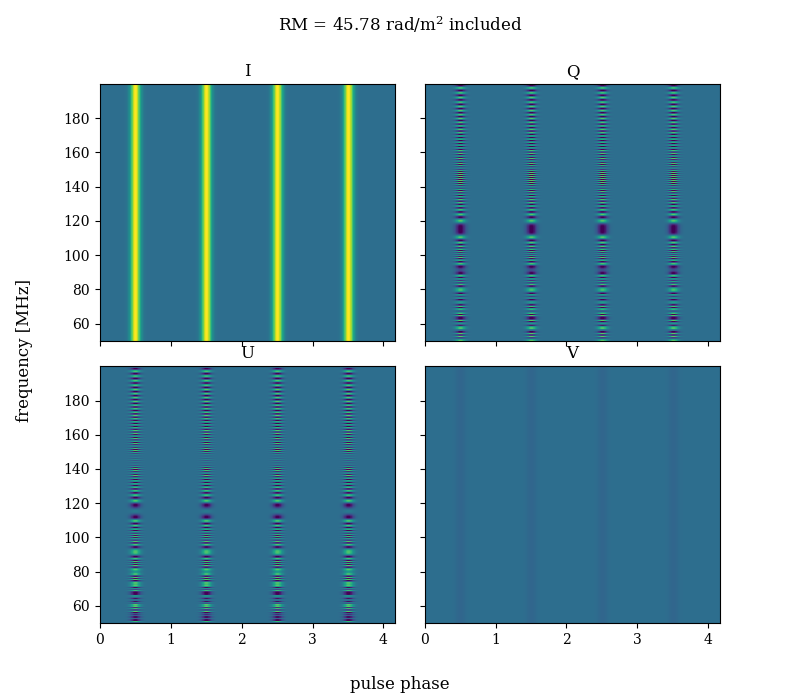

In [11]:
I = signal_1.data
pL = 0.6 # linear polarization fraction
pV = -0.05 # circular polarization fraction
L = I * pL # linearly polarized light
psi = np.deg2rad(80) # polarization angle
Q = L * np.cos(2*psi)
U = L * np.sin(2*psi)
V = I * pV

full_stokes = np.array([I,Q,U,V])

cmap='viridis'

fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(8,7))
ax[0,0].imshow(I, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[0,0].set_title('I')
ax[0,1].imshow(Q, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[0,1].set_title('Q')
ax[1,0].imshow(U, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[1,0].set_title('U')
ax[1,1].imshow(V, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[1,1].set_title('V')
#plt.xlim(0,10)
plt.subplots_adjust(hspace=0.1, wspace=0.1)
fig.supxlabel('pulse phase')
fig.supylabel('frequency [MHz]')
fig.suptitle('RM not included')
plt.show()

# incorporate RM
freq = signal_1.dat_freq.value * 1e6
lam = 3e8/freq 
RM = 45.78 # rad/m^2, 45.78 for J0630-2834

psivec = RM*lam**2 + psi

Q = L * np.cos(2*psivec)[:,None]
U = L * np.sin(2*psivec)[:,None]

fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(8,7))
ax[0,0].imshow(I, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[0,0].set_title('I')
ax[0,1].imshow(Q, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[0,1].set_title('Q')
ax[1,0].imshow(U, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[1,0].set_title('U')
ax[1,1].imshow(V, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[1,1].set_title('V')
#plt.xlim(0,10)
plt.subplots_adjust(hspace=0.1, wspace=0.1)
fig.supxlabel('pulse phase')
fig.supylabel('frequency [MHz]')
fig.suptitle(f'RM = {RM} rad/m$^2$ included')
plt.show()

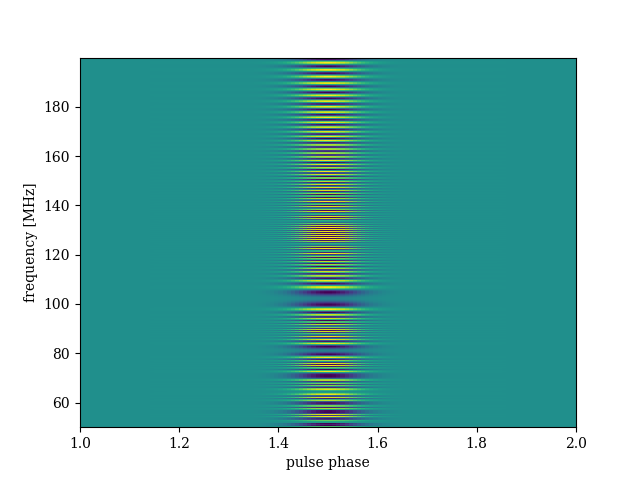

In [12]:
plt.figure()
plt.imshow(Q, aspect='auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value])
plt.xlim(1,2)
plt.xlabel('pulse phase')
plt.ylabel('frequency [MHz]')
plt.show()

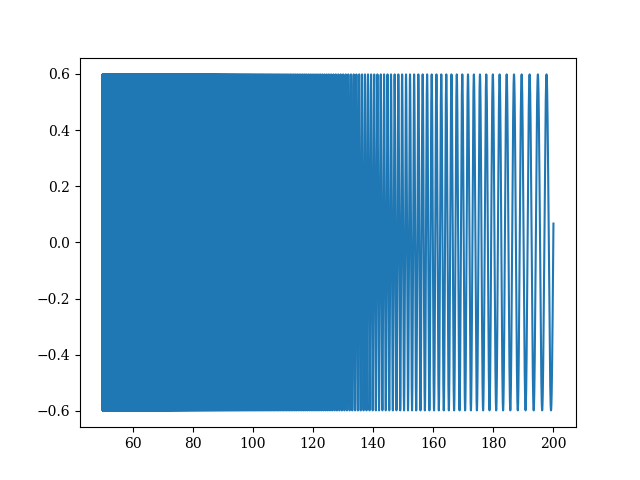

In [15]:
plt.figure()
plt.plot(freq/1e6, Q[:,np.argmin(np.abs(phases-1.5))])
#plt.xlim(0, 10)
plt.show()

1229.996096933861 256.0008123480506 50.0 10.0
0.1171875
(10, 1230)


/var/folders/b_/601lqv7d3mg79nf_9cc89gd40000gn/T/ipykernel_25821/3623588004.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


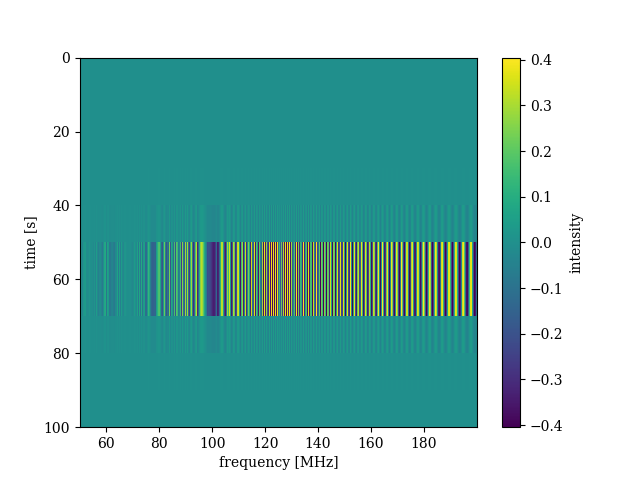

In [30]:
def downbin(a, stokes, phases, fbin=0.122, tbin=9.6636):
    nf = (a.dat_freq[-1].value-a.dat_freq[0].value)/fbin+1
    nt = a.tobs.value/tbin
    nfpb = len(a.data)/nf
    ntpb = len(a.data[0])/nt
    print(nf, nfpb, nt, ntpb)
    arr = stokes.reshape(int(round(nf)), int(round(nfpb)), int(round(nt)), int(round(ntpb)))
    arr = np.average(arr, axis=3)
    arr = np.average(arr, axis=1)
    return arr

phases = np.linspace(0, obslen/period, len(signal_1.data[0,:]))
a = downbin(signal_1, Q, phases, fbin=150/(1230-1), tbin=0.1)
print(0.5859375/5)

plt.figure()
print(a.T[:10].shape)
plt.imshow(a.T[:10], aspect = 'auto', interpolation='none', origin = 'upper', \
           extent = [signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value, 100, 0],  cmap='viridis')
plt.xlabel('frequency [MHz]')
plt.ylabel('time [s]')
plt.colorbar(label = 'intensity')
#plt.xlim(100,120)
#plt.ylim(0,500)
#np.save('DMbeat_spectrum.npy', a.T)

plt.show()

In [20]:
1230*256*400

125952000